TP1- California Housing Price Prediction

1- Business framing : 

- The Machine‑Learning task is supervised
- regression 

Performance metric

- Which error metric would you propose first and why?  : RMSE because it penalizes large errors more strongly
- When might MAE be preferable? : MAE is preferable if the data contains outliers and you want a more robust metric





In [1]:
import os, tarfile, urllib.request
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL  = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url: str = HOUSING_URL, housing_path: str = HOUSING_PATH):
    """Download & uncompress the California housing dataset."""
    #  ensure local directory exists
    os.makedirs(housing_path, exist_ok=True)

    #  download the archive only if it isn’t already present
    tgz_path = os.path.join(housing_path, "housing.tgz")
    if not os.path.isfile(tgz_path):
        print(" Downloading …")
        urllib.request.urlretrieve(housing_url, tgz_path)

    #  extract csv
    with tarfile.open(tgz_path) as housing_tgz:
        housing_tgz.extractall(path=housing_path)
    print(" Dataset ready at", housing_path)



In [2]:
fetch_housing_data()

 Dataset ready at datasets\housing


C:\Users\mariy\AppData\Local\Temp\ipykernel_27984\1202889753.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [3]:
pip install pandas 


Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
def load_housing_data(housing_path: str = HOUSING_PATH) -> pd.DataFrame:
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)
housing = load_housing_data()


In [5]:
# Afficher les 5 premières lignes
print("First 5 rows:")
print(housing.head())

# Afficher la forme du DataFrame
print("\nShape of the dataset:")
print(housing.shape)

# Afficher la liste des colonnes
print("\nColumns:")
print(housing.columns.tolist())

# Identifier la variable cible possible
print("\nBased on the column names, 'median_house_value' looks like the target variable.")

First 5 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Shape of the dataset:
(20640, 10)

Columns:
['longitude', 'l

2 | Quick Data Inspection
2.1 Structure & basic stats
#Which numeric attribute has the largest standard deviation? 
housing.describe()
#Any missing values?
total_bedrooms
#How many instances/observations in the dataset ? 
From housing.info()
20,640 rows 

#Use info and describe python method 

#You can find out what categories exist and how many districts belong to each category by using the value_counts() method
These are the five categories for ocean_proximity, along with their counts

In [6]:
pip install matplotlib 

Note: you may need to restart the kernel to use updated packages.


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

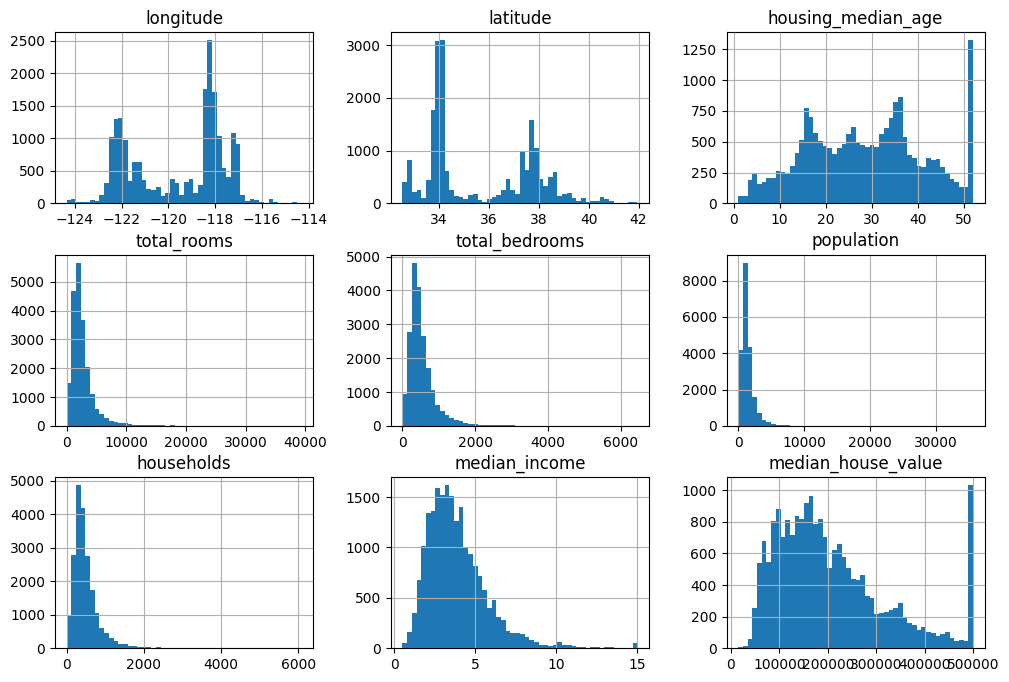

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(12,8))

Creating a Reliable Test Set    


If we adjust the hyperparameters on the test set:

Data leak

Overly optimistic score

Model unusable in production

In [8]:
import numpy as np

def split_train_test(data, test_ratio=0.2, seed=42):
    """Return train_df, test_df using a random permutation."""
    np.random.seed(seed)                # 🔒 repeatability
    shuffled_idx   = np.random.permutation(len(data))
    test_set_size  = int(len(data) * test_ratio)
    test_idx       = shuffled_idx[:test_set_size]
    train_idx      = shuffled_idx[test_set_size:]
    return data.iloc[train_idx], data.iloc[test_idx]

train_set, test_set = split_train_test(housing, test_ratio=0.2)
print(len(train_set), len(test_set))


16512 4128


It guarantees the reproducibility of the random draw

In [9]:
pip install scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [10]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

Stratified Sampling
● Comparison of Proportions

Yes, the stratified set test almost exactly matches the overall distribution.

The random split shows significant discrepancies (especially for rare categories).

● Conclusion

The stratified test is preferable.

In [11]:
housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_idx]
    strat_test_set  = housing.loc[test_idx]

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [12]:
for _set in (strat_train_set, strat_test_set):
    _set.drop("income_cat", axis=1, inplace=True)

Discover & Visualize the Training Data


In [13]:
# Always explore *only* the training fold
housing = strat_train_set.copy()

Description

Map of California
Higher population density near the coasts

<Axes: xlabel='longitude', ylabel='latitude'>

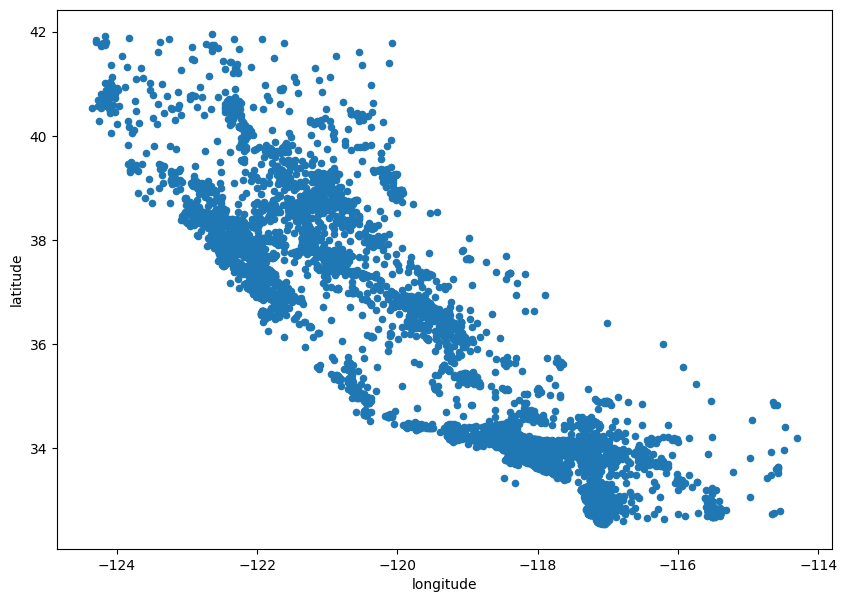

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7))

<Axes: xlabel='longitude', ylabel='latitude'>

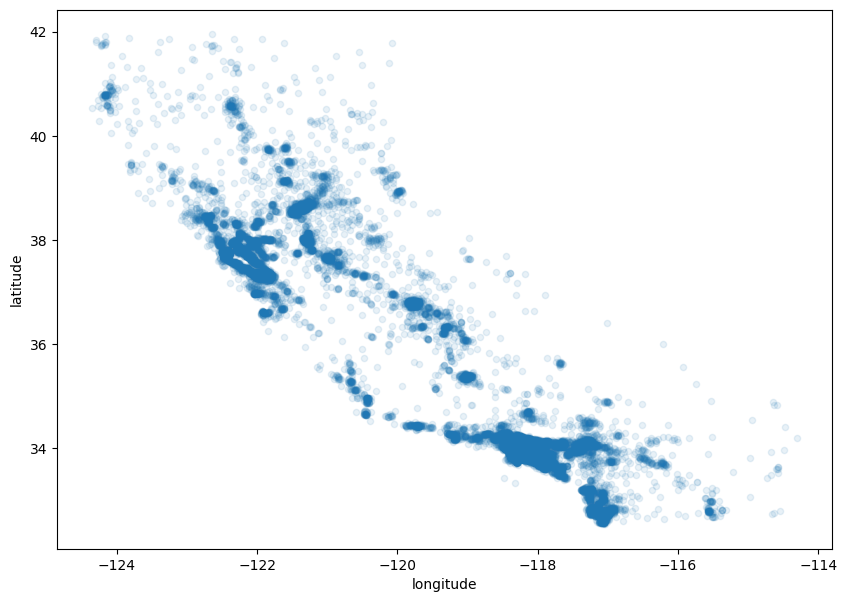

In [15]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, figsize=(10,7))

With transparency (alpha=0.1)

High density:

Los Angeles

San Francisco

San Diego

Housing Prices on the Map

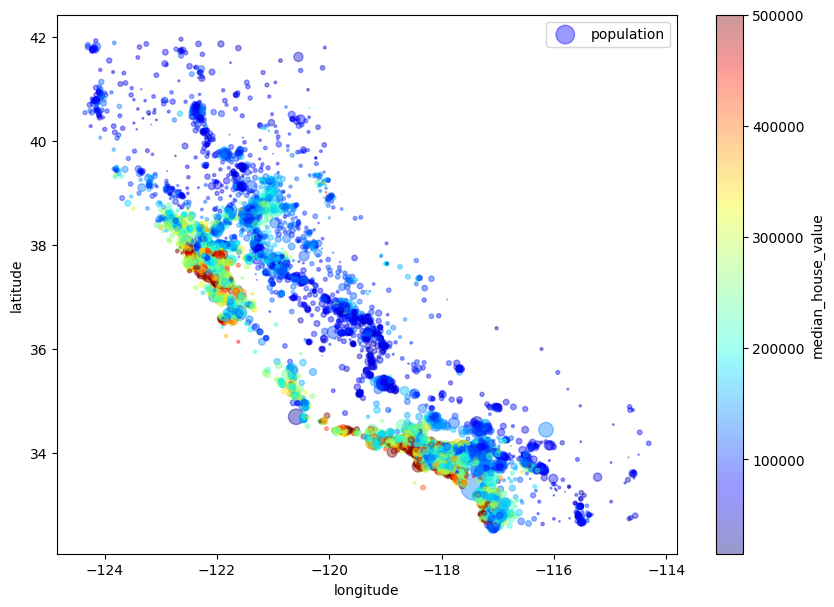

In [16]:
import matplotlib.pyplot as plt

housing.plot(
    kind="scatter", x="longitude", y="latitude", alpha=0.4, figsize=(10,7),
    s=housing["population"] / 100,              # bubble size
    label="population",
    c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.legend()


Variables most closely linked to high prices

Latitude/Longitude (proximity to the coast)
Median income

In [18]:
pip install jinja2 

Note: you may need to restart the kernel to use updated packages.


In [19]:
corr_matrix = housing.corr(numeric_only=True)
print(corr_matrix["median_house_value"].sort_values(ascending=False))
corr_matrix.style.background_gradient(cmap='coolwarm',).format(precision=2)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.00,-0.92,-0.11,0.05,0.08,0.11,0.06,-0.02,-0.05
latitude,-0.92,1.00,0.01,-0.04,-0.07,-0.12,-0.08,-0.08,-0.14
housing_median_age,-0.11,0.01,1.00,-0.36,-0.33,-0.30,-0.31,-0.11,0.11
total_rooms,0.05,-0.04,-0.36,1.00,0.93,0.86,0.92,0.20,0.14
total_bedrooms,0.08,-0.07,-0.33,0.93,1.00,0.88,0.98,-0.01,0.05
population,0.11,-0.12,-0.30,0.86,0.88,1.00,0.90,0.00,-0.03
households,0.06,-0.08,-0.31,0.92,0.98,0.90,1.00,0.01,0.06
median_income,-0.02,-0.08,-0.11,0.20,-0.01,0.00,0.01,1.00,0.69
median_house_value,-0.05,-0.14,0.11,0.14,0.05,-0.03,0.06,0.69,1.00


Strongest positive correlation

median income

Strongest negative correlation

latitude (northernmost, cheaper)

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

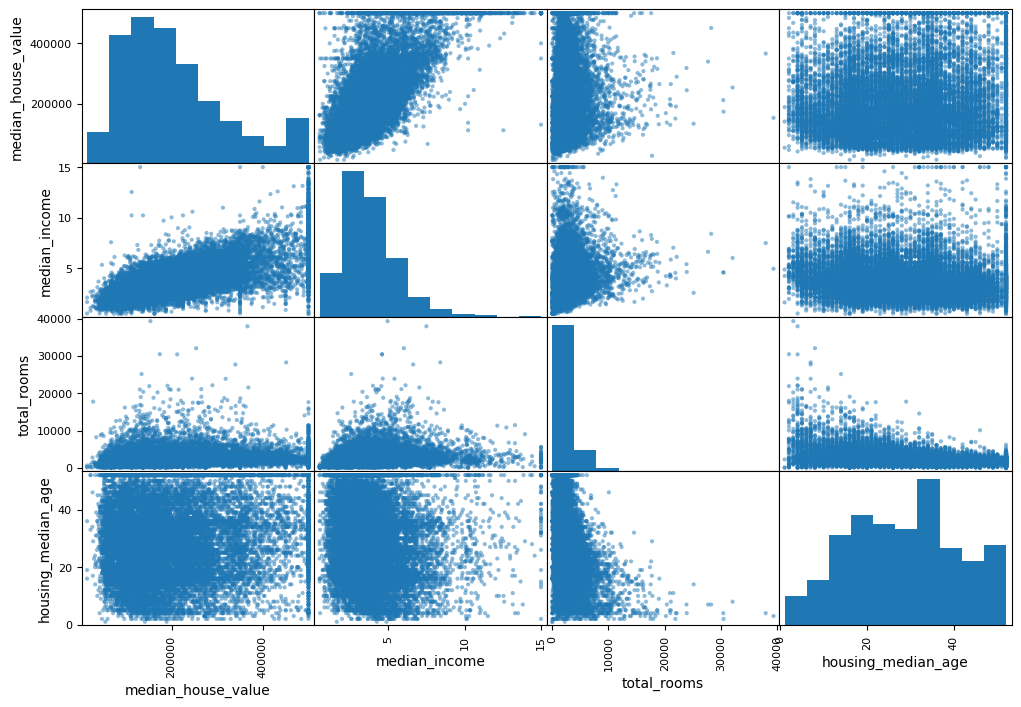

In [20]:
from pandas.plotting import scatter_matrix
sel_attrs = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[sel_attrs], figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

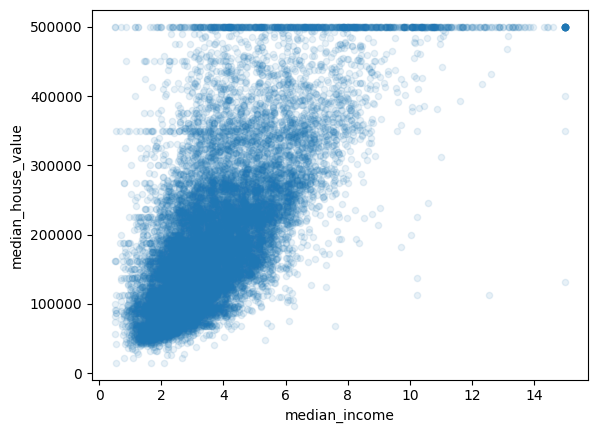

In [21]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

Observed Artifacts

Horizontal lines at:

500,000

450,000

Values ​​artificially capped

Possible rule

Remove districts where median_house_value >= 500,000

Feature Engineering — Attribute Combinations


Top 5 correlations with price

median income

rooms per household

total rooms

median age of household

population per household

Interpretation of bedrooms per room

Low ratio → more spacious/luxurious housing

Negative correlation with price

In [22]:
housing_fe = housing.copy()  # fresh working copy
housing_fe["rooms_per_household"]      = housing_fe["total_rooms"] / housing_fe["households"]
housing_fe["bedrooms_per_room"]        = housing_fe["total_bedrooms"] / housing_fe["total_rooms"]
housing_fe["population_per_household"] = housing_fe["population"]    / housing_fe["households"]


Data Preparation Pipeline

In [23]:
housing_prep = strat_train_set.drop("median_house_value", axis=1).copy()
housing_labels = strat_train_set["median_house_value"].copy()

In [24]:

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
housing_num = housing_prep.drop(["ocean_proximity"], axis=1)
num_attribs = list(housing_num)
imputer.fit(housing_num)
imputer.statistics_
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
cat_attribs = ["ocean_proximity"]
oneHot = ColumnTransformer([
	("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs)
])
housing_oneHot = oneHot.fit_transform(housing_prep)


Feature Scaling 

 MinMaxScaler : Neural Network ; KNN

StandardScaler : Linear Regression



Custom Transformers (Class-Based)

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# column indices within the numeric array (after ColumnTransformer selects num_attribs)
rooms_ix, bedrooms_ix, population_ix, households_ix = ( num_attribs.index("total_rooms"),num_attribs.index("total_bedrooms"),
num_attribs.index("population"), num_attribs.index("households"))
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room: bool = True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix]/ X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        return np.c_[X, rooms_per_household, population_per_household]
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder(add_bedrooms_per_room=True)),
    ("scaler", StandardScaler()),
])

Full Pre‑processing (Numerical + Categorical)


In [26]:
from sklearn.preprocessing import OneHotEncoder
full_pipeline = ColumnTransformer([
	 ("num", num_pipeline, num_attribs),
	("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs)
])
housing_prepared = full_pipeline.fit_transform(housing_prep)
full_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Sanity Baseline: Constant Predictor

In [27]:
import numpy as np
from sklearn.metrics import mean_squared_error
X_train = housing_prepared            # from Section 7.3
y_train = housing_labels
# baseline that always predicts the training median
baseline_pred = np.full_like(y_train, fill_value=y_train.median(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_train, baseline_pred))
print(f"Baseline (median) RMSE on training: {baseline_rmse:,.0f}")

Baseline (median) RMSE on training: 118,922


RMSE ≈ target std


The model learns nothing : minimal reference


Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
some_data = housing_prep.iloc[:5]
some_labels = y_train.iloc[:5]
some_data_prepared = full_pipeline.transform(some_data)
print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))
lin_rmse = np.sqrt(mean_squared_error(y_train, lin_reg.predict(X_train)))
print(f"Linear Regression RMSE (train): {lin_rmse:,.0f}")


Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]
Linear Regression RMSE (train): 68,628


Yes. RMSE ≈ 70k while prices go up to 500k. Too simple a model.

Decision Tree (Watch for Overfitting)

In [29]:
from sklearn.tree import DecisionTreeRegressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)
tree_rmse_train = np.sqrt(mean_squared_error(y_train, tree_reg.predict(X_train)))
print(f"DecisionTree RMSE (train): {tree_rmse_train:,.0f}")


DecisionTree RMSE (train): 0


NO
 Overfitting massif

Cross‑Validation Utility

In [30]:
import numpy as np
from sklearn.model_selection import cross_val_score

def rmse_cv(estimator, X, y, cv=10):
    neg_mse = cross_val_score(
        estimator,
        X,
        y,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    return np.sqrt(-neg_mse)  # array of RMSEs


# Compare Linear vs Tree
lin_rmse_cv  = rmse_cv(lin_reg,  X_train, y_train)
tree_rmse_cv = rmse_cv(tree_reg, X_train, y_train)

def display_scores(name, scores):
    print(f"{name} CV RMSEs: {np.round(scores, 0)}")
    print(f"Mean: {scores.mean():,.0f}  |  Std: {scores.std():,.0f}")

display_scores("Linear", lin_rmse_cv)
display_scores("Tree", tree_rmse_cv)


Linear CV RMSEs: [71763. 64115. 67771. 68635. 66846. 72528. 73997. 68802. 66443. 70140.]
Mean: 69,104  |  Std: 2,880
Tree CV RMSEs: [72831. 69973. 69529. 72518. 69146. 79095. 68960. 73345. 69826. 71077.]
Mean: 71,630  |  Std: 2,914


Random Forest (Ensemble)

In [31]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
forest_reg.fit(X_train, y_train)
forest_rmse_cv = rmse_cv(forest_reg, X_train, y_train)
display_scores("RandomForest", forest_rmse_cv)

RandomForest CV RMSEs: [51353. 48668. 46576. 51948. 47508. 51724. 52284. 49735. 48452. 53911.]
Mean: 50,216  |  Std: 2,254


Analyse biais / variance

Linear : biais élevé

Tree : variance élevée

Forest : meilleur compromis

Supériorité

RMSE moyen plus faible

Variance plus stable


Try a Couple More Models


In [32]:
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
svr_rbf = SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.2)
mlp = MLPRegressor(hidden_layer_sizes=(128,64), activation="relu",
                   learning_rate_init=1e-3, random_state=42, max_iter=500)
for name, est in [("SVR-RBF", svr_rbf), ("MLP", mlp)]:
    scores = rmse_cv(est, X_train, y_train, cv=5)  # 5-fold to save time
    display_scores(name, scores)


SVR-RBF CV RMSEs: [116007. 114523. 116378. 116629. 117079.]
Mean: 116,123  |  Std: 873


c:\Users\mariy\Desktop\school\EMLV\machine learning\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\mariy\Desktop\school\EMLV\machine learning\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\mariy\Desktop\school\EMLV\machine learning\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\mariy\Desktop\school\EMLV\machine learning\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5

MLP CV RMSEs: [61813. 60582. 63761. 65308. 63286.]
Mean: 62,950  |  Std: 1,627


c:\Users\mariy\Desktop\school\EMLV\machine learning\.venv312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Fine‑Tune Your Model

In [ ]:
Save Your Work (Models & Metadata) 

In [34]:
import joblib
results = {
    "baseline_rmse": float(baseline_rmse),
    "lin_cv":  (float(lin_rmse_cv.mean()),  float(lin_rmse_cv.std())),
    "tree_cv": (float(tree_rmse_cv.mean()), float(tree_rmse_cv.std())),
    "forest_cv": (float(forest_rmse_cv.mean()), float(forest_rmse_cv.std())),
}
os.makedirs("models", exist_ok=True)
joblib.dump({
    "pipeline": full_pipeline,
    "lin_reg": lin_reg,
    "tree_reg": tree_reg,
    "forest_reg": forest_reg,
    "cv_results": results,
}, "models/first_pass_models.joblib")
print("✓ Saved models to models/first_pass_models.joblib")


✓ Saved models to models/first_pass_models.joblib


Grid Search (on the Full Pipeline)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

full_model = Pipeline([
    ("preprocess", full_pipeline),       # from Section 7.3 (ColumnTransformer)
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])
param_grid = [
    {
        "model__n_estimators": [50, 100, 200],
        "model__max_features": ["sqrt", 4, 6, 8],
        "model__max_depth": [None, 20, 30],
        # Try toggling a preprocessing hyperparameter too (if using CombinedAttributesAdder)
        "preprocess__num__attribs_adder__add_bedrooms_per_room": [True,
False],
    },
    {
        "model__bootstrap": [False],
        "model__n_estimators": [50, 100],
        "model__max_features": [4, 6, 8],
    },
]
grid_search = GridSearchCV(
    estimator=full_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",   # higher is better → negative MSE
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(housing_prep, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__max_depth': [None, 20, ...], 'model__max_features': ['sqrt', 4, ...], 'model__n_estimators': [50, 100, ...], 'preprocess__num__attri...__add_bedrooms_per_room': [True, False]}, {'model__bootstrap': [False], 'model__max_features': [4, 6, ...], 'model__n_estimators': [50, 100]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` def